In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report, confusion_matrix

In [3]:
import os

folders = [
    "data",
    "notebooks",
    "outputs",
    "figures",
    "figures/eda_plots",
    "figures/model_plots",
    "models",
]

for folder in folders:
    os.makedirs(folder, exist_ok=True)

print("Folder structure created successfully.")

Folder structure created successfully.


In [5]:
train = pd.read_csv("data/dataset_C_training.csv")
test = pd.read_csv("data/dataset_C_testing.csv")

print("Train shape:", train.shape)
print("Test shape:", test.shape)

display(train.head())
display(test.head())

Train shape: (4756, 31)
Test shape: (4749, 30)


,respondent_id,covid_concern,covid_knowledge,behavioral_antiviral_meds,behavioral_avoidance,behavioral_face_mask,behavioral_wash_hands,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,...,employment_status,census_msa,household_adults,household_children,doctor_recc_covid,opinion_covid_vacc_effective,opinion_covid_risk,opinion_covid_sick_from_vacc,employment_sector,covid_vaccine
0,1,3.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,...,Employed,"MSA, Principle City",3.0,2.0,0,4,4,2.0,construction,0
1,2,2.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,...,Employed,Non-MSA,0.0,0.0,0,5,2,1.0,education,1
2,3,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,Employed,"MSA, Not Principle City",0.0,0.0,0,2,2,5.0,wholesale,0
3,4,2.0,2.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,...,Not in Labor Force,"MSA, Not Principle City",1.0,0.0,1,3,3,2.0,NaN,1
4,5,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,Employed,"MSA, Not Principle City",0.0,0.0,0,3,2,2.0,wholesale,0


,respondent_id,covid_concern,covid_knowledge,behavioral_antiviral_meds,behavioral_avoidance,behavioral_face_mask,behavioral_wash_hands,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,...,rent_or_own,employment_status,census_msa,household_adults,household_children,doctor_recc_covid,opinion_covid_vacc_effective,opinion_covid_risk,opinion_covid_sick_from_vacc,employment_sector
0,4757,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,...,Own,Not in Labor Force,"MSA, Principle City",0.0,0.0,0,4,2,2.0,NaN
1,4758,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,NaN,NaN,"MSA, Not Principle City",0.0,0.0,0,2,3,2.0,NaN
2,4759,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,...,Own,Not in Labor Force,"MSA, Principle City",1.0,0.0,0,3,2,2.0,NaN
3,4760,3.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,...,Rent,Employed,Non-MSA,1.0,0.0,0,4,4,1.0,agriculture
4,4761,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,Own,Employed,Non-MSA,0.0,0.0,0,3,2,1.0,wholesale


In [6]:
target = "covid_vaccine"
id_col = "respondent_id"

X = train.drop(columns=[target, id_col])
y = train[target]

X_test_final = test.drop(columns=[id_col])

numeric_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()

print("Numeric columns:", numeric_cols)
print("Categorical columns:", categorical_cols)

Numeric columns: ['covid_concern', 'covid_knowledge', 'behavioral_antiviral_meds', 'behavioral_avoidance', 'behavioral_face_mask', 'behavioral_wash_hands', 'behavioral_large_gatherings', 'behavioral_outside_home', 'behavioral_touch_face', 'chronic_med_condition', 'child_under_6_months', 'health_worker', 'health_insurance', 'household_adults', 'household_children', 'doctor_recc_covid', 'opinion_covid_vacc_effective', 'opinion_covid_risk', 'opinion_covid_sick_from_vacc']
Categorical columns: ['age_group', 'education', 'race', 'sex', 'income_poverty', 'marital_status', 'rent_or_own', 'employment_status', 'census_msa', 'employment_sector']


In [7]:
X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [8]:
numeric_transformer_svm = Pipeline(steps=[
    ("imputer", KNNImputer(n_neighbors=5)),
    ("scaler", StandardScaler())
])

categorical_transformer_svm = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value="Unknown")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor_svm = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer_svm, numeric_cols),
        ("cat", categorical_transformer_svm, categorical_cols)
    ]
)

In [9]:
svm_model = Pipeline(steps=[
    ("preprocessor", preprocessor_svm),
    ("classifier", SVC(
        kernel="rbf",
        C=1.5,
        gamma="scale",
        probability=True,
        class_weight="balanced",
        random_state=42
    ))
])

svm_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   KNNImputer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['covid_concern',
                                                   'covid_knowledge',
                                                   'behavioral_antiviral_meds',
                                                   'behavioral_avoidance',
                                                   'behavioral_face_mask',
                                                   'behavioral_wash_hands',
                                                   'behavioral_large_gatherings',
                                                   'behavioral_outside_home',
                                                   'behavioral_touch_f...
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='Unknown',
                                                                                 strategy='constant')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['age_group', 'education',
                                                   'race', 'sex',
                                                   'income_poverty',
                                                   'marital_status',
                                                   'rent_or_own',
                                                   'employment_status',
                                                   'census_msa',
                                                   'employment_sector'])])),
                ('classifier',
                 SVC(C=1.5, class_weight='balanced', probability=True,
                     random_state=42))])

In [10]:
valid_probs = svm_model.predict_proba(X_valid)[:, 1]
valid_preds = (valid_probs >= 0.5).astype(int)

print("SVM Results with Default Threshold 0.5")
print("Accuracy:", accuracy_score(y_valid, valid_preds))
print("F1 Score:", f1_score(y_valid, valid_preds))
print("ROC-AUC:", roc_auc_score(y_valid, valid_probs))
print(classification_report(y_valid, valid_preds))

SVM Results with Default Threshold 0.5
Accuracy: 0.7689075630252101
F1 Score: 0.6258503401360545
ROC-AUC: 0.822340996533752
              precision    recall  f1-score   support

           0       0.81      0.85      0.83       641
           1       0.66      0.59      0.63       311

    accuracy                           0.77       952
   macro avg       0.74      0.72      0.73       952
weighted avg       0.76      0.77      0.77       952



In [11]:
thresholds = np.arange(0.1, 0.9, 0.01)

best_threshold = 0.5
best_f1 = 0

for threshold in thresholds:
    temp_preds = (valid_probs >= threshold).astype(int)
    temp_f1 = f1_score(y_valid, temp_preds)

    if temp_f1 > best_f1:
        best_f1 = temp_f1
        best_threshold = threshold

print("Best Threshold:", best_threshold)
print("Best F1 Score:", best_f1)

Best Threshold: 0.32999999999999985
Best F1 Score: 0.6725403817914831


In [12]:
valid_preds_tuned = (valid_probs >= best_threshold).astype(int)

print("SVM Results with Tuned Threshold")
print("Accuracy:", accuracy_score(y_valid, valid_preds_tuned))
print("F1 Score:", f1_score(y_valid, valid_preds_tuned))
print("ROC-AUC:", roc_auc_score(y_valid, valid_probs))
print(classification_report(y_valid, valid_preds_tuned))

SVM Results with Tuned Threshold
Accuracy: 0.7657563025210085
F1 Score: 0.6725403817914831
ROC-AUC: 0.822340996533752
              precision    recall  f1-score   support

           0       0.86      0.78      0.82       641
           1       0.62      0.74      0.67       311

    accuracy                           0.77       952
   macro avg       0.74      0.76      0.75       952
weighted avg       0.78      0.77      0.77       952



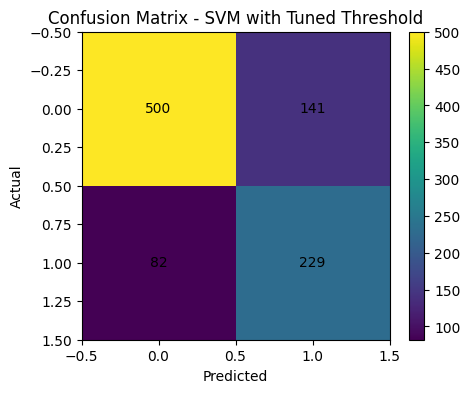

In [13]:
cm = confusion_matrix(y_valid, valid_preds_tuned)

plt.figure(figsize=(5, 4))
plt.imshow(cm)
plt.title("Confusion Matrix - SVM with Tuned Threshold")
plt.colorbar()
plt.xlabel("Predicted")
plt.ylabel("Actual")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.savefig("figures/model_plots/svm_confusion_matrix.png", bbox_inches="tight")
plt.show()

In [14]:
test_probs = svm_model.predict_proba(X_test_final)[:, 1]

SVMValues = pd.DataFrame({
    "respondent_id": test["respondent_id"],
    "covid_vaccine": test_probs
})

SVMValues.head()

,respondent_id,covid_vaccine
0,4757,0.174557
1,4758,0.101629
2,4759,0.163461
3,4760,0.500000
4,4761,0.080136


In [15]:
SVMValues.to_csv("outputs/SVMValues.csv", index=False)

print("SVMValues.csv saved successfully")

SVMValues.csv saved successfully


In [16]:
pd.read_csv("outputs/SVMValues.csv").head()

,respondent_id,covid_vaccine
0,4757,0.174557
1,4758,0.101629
2,4759,0.163461
3,4760,0.500000
4,4761,0.080136


In [17]:
!git clone https://github.com/Research-Methods-hackathon/Hackathon_GroupV.git

Cloning into 'Hackathon_GroupV'...
remote: Enumerating objects: 74, done.
remote: Counting objects: 100% (74/74), done.
remote: Compressing objects: 100% (64/64), done.
remote: Total 74 (delta 22), reused 37 (delta 3), pack-reused 0 (from 0)
Receiving objects: 100% (74/74), 1.11 MiB | 5.73 MiB/s, done.
Resolving deltas: 100% (22/22), done.


In [18]:
%cd Hackathon_GroupV/

/content/Hackathon_GroupV


In [19]:
!git config --global user.email "taruninallamothu24@gmail.com"
!git config --global user.name "taruni2409"

In [20]:
!git add .
!git commit -m "Added SVM model with hyperparameter tuning"

On branch main
Your branch is up to date with 'origin/main'.

nothing to commit, working tree clean


In [21]:
from getpass import getpass

username = "taruni2409"
token = getpass("Paste GitHub token: ")

repo_url = "https://github.com/Research-Methods-hackathon/Hackathon_GroupV.git"
auth_repo_url = repo_url.replace("https://", f"https://{username}:{token}@")

!git remote set-url origin {auth_repo_url}
!git push origin main

!git remote set-url origin https://github.com/Research-Methods-hackathon/Hackathon_GroupV.git

Paste GitHub token: ··········
Everything up-to-date
